In [1]:
import uproot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm


In [2]:
def make_df(file_path):
    df = pd.DataFrame()

    tritrig_file = uproot.open(file_path)

    # Open ROOT tree
    tree = tritrig_file['preselection']

    # Access branches
    B_vertex = tree['vertex.']
    B_ele = tree['ele.']
    B_pos = tree['pos.']


    # Get vertex positions
    vertex_pos = B_vertex['vertex.pos_'].array()
    #df['vertex_pos_x'] = np.array(vertex_pos['fX'])
    #df['vertex_pos_y'] = np.array(vertex_pos['fY'])
    #df['vertex_pos_z'] = np.array(vertex_pos['fZ'])

    # Get arrays of the electron and positron energies as measured with Ecal
    df['ele_E_Ecal'] = np.array(B_ele['ele.energy_'])
    df['pos_E_Ecal'] = np.array(B_pos['pos.energy_'])
    # Get number of hits in Ecal clusters
    df['ele_Ecal_nhits'] = np.array(tree['ele_clu_nhits'])
    df['pos_Ecal_nhits'] = np.array(tree['pos_clu_nhits'])
    # Get Ecal cluster positions
    df['ele_Ecal_x']= np.array(B_ele['ele.cluster_.x_'])
    df['ele_Ecal_y']= np.array(B_ele['ele.cluster_.y_'])
    df['ele_Ecal_z']= np.array(B_ele['ele.cluster_.z_'])
    df['pos_Ecal_x']= np.array(B_pos['pos.cluster_.x_'])
    df['pos_Ecal_y']= np.array(B_pos['pos.cluster_.y_'])
    df['pos_Ecal_z']= np.array(B_pos['pos.cluster_.z_'])

    # Get number of hits on track
    #df['ele_trk_nhits'] = np.array(B_ele[ 'ele.track_/ele.track_.n_hits_'])
    #df['pos_trk_nhits'] = np.array(B_pos[ 'pos.track_/pos.track_.n_hits_'])
    # Get Electron and Positron momenta
    arr = B_vertex['vertex.p1_'].array()
    df['ele_Px'] = np.array(arr['fX'])
    df['ele_Py'] = np.array(arr['fY'])
    df['ele_Pz'] = np.array(arr['fZ'])
    arr = B_vertex['vertex.p2_'].array()
    df['pos_Px'] = np.array(arr['fX'])
    df['pos_Py'] = np.array(arr['fY'])
    df['pos_Pz'] = np.array(arr['fZ'])
    # Collect track parameters for electrons and positrons
    #df['ele_phi0'] = -np.array(B_ele['ele.track_/ele.track_.phi0_'])
    #df['ele_dp'] = np.array(B_ele['ele.track_/ele.track_.d0_'])
    #df['ele_kappa_o_alpha'] = -np.array(B_ele['ele.track_/ele.track_.omega_'])
    #df['ele_dz'] = -np.array(B_ele['ele.track_/ele.track_.z0_'])
    #df['ele_tan_lambda'] = -np.array(B_ele['ele.track_/ele.track_.tan_lambda_'])
    #df['pos_phi0'] = -np.array(B_pos['pos.track_/pos.track_.phi0_'])
    #df['pos_dp'] = np.array(B_pos['pos.track_/pos.track_.d0_'])
    #df['pos_kappa_o_alpha'] = -np.array(B_pos['pos.track_/pos.track_.omega_'])
    #df['pos_dz'] = -np.array(B_pos['pos.track_/pos.track_.z0_'])
    #df['pos_tan_lambda'] = -np.array(B_pos['pos.track_/pos.track_.tan_lambda_'])

    return df


In [3]:
# Create dataframes 
df_tritrig_1 = make_df('/Users/mghrear/data/HPS_mc/2019_tritrig_pulser_recon_2/tritrig.root')
df_tritrig_2 = make_df('/Users/mghrear/data/HPS_mc/2019_tritrig_pulser_recon_2_pt2/tritrig.root')
df_phiKK = make_df('/Users/mghrear/data/HPS_mc/2019_phiKK_patch_pulser_recon/phiKK.root')
df_wab_2 = make_df('/Users/mghrear/data/HPS_mc/2019_WAB_pulser_recon_2/wab.root')
df_wab_1 = make_df('/Users/mghrear/data/HPS_mc/2019_WAB_pulser_recon_1/wab.root')
df_data = make_df('/Users/mghrear/data/HPS_data/2019_run010051/2019_run010051.root')


df_tritrig = pd.concat([df_tritrig_1, df_tritrig_2], ignore_index=True, sort=False)
df_wab = pd.concat([df_wab_1, df_wab_2], ignore_index=True, sort=False)




/var/folders/fx/czrkltw953xcpcjd85tf2tmm0000gn/T/ipykernel_16713/3109213581.py:40: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  df['ele_Px'] = np.array(arr['fX'])
/var/folders/fx/czrkltw953xcpcjd85tf2tmm0000gn/T/ipykernel_16713/3109213581.py:41: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  df['ele_Py'] = np.array(arr['fY'])
/var/folders/fx/czrkltw953xcpcjd85tf2tmm0000gn/T/ipykernel_16713/3109213581.py:42: DeprecationWarning: __array__ implementation doesn't accept a copy 

In [111]:
df_tritrig.to_pickle('/Users/mghrear/data/ML_data/patch/BDT_2019_tritrig_limited.pk')
df_phiKK.to_pickle('/Users/mghrear/data/ML_data/patch/BDT_2019_phiKK_limited.pk')
df_wab.to_pickle('/Users/mghrear/data/ML_data/patch/BDT_2019_wab_limited.pk')
df_data.to_pickle('/Users/mghrear/data/ML_data/patch/BDT_2019_data_limited.pk')

# Compare these attributes in data vs. monte carlo 

In [5]:
df_tritrig_study = df_tritrig.copy()
df_phiKK_study = df_phiKK.copy()
df_wab_study = df_wab.copy()
df_data_study = df_data.copy()

In [8]:
# Calculate invariant mass and add to dataframe
m_K = 0.493677

def calculate_invariant_mass_Ptot(df):
    # Calculate total electron momentum
    df['e_Ptot'] = np.sqrt(df['ele_Px']**2 + df['ele_Py']**2 + df['ele_Pz']**2)
    # Calculate total positron momentum
    df['p_Ptot'] = np.sqrt(df['pos_Px']**2 + df['pos_Py']**2 + df['pos_Pz']**2)
    df['e_SVT_E_K'] = m_K / np.sqrt ( 1 - ( df.e_Ptot**2 / (df.e_Ptot**2  + m_K**2) ) )
    df['p_SVT_E_K'] = m_K / np.sqrt ( 1 - ( df.p_Ptot**2 / (df.p_Ptot**2  + m_K**2) ) )
    df['M'] = np.sqrt((df.e_SVT_E_K+df.p_SVT_E_K)**2 - (df.ele_Px+df.pos_Px)**2 - (df.ele_Py+df.pos_Py)**2 - (df.ele_Pz+df.pos_Pz)**2)
    df['Ptot'] = df.e_Ptot + df.p_Ptot

    return df

df_tritrig_study = calculate_invariant_mass_Ptot(df_tritrig_study)
df_phiKK_study = calculate_invariant_mass_Ptot(df_phiKK_study)
df_wab_study = calculate_invariant_mass_Ptot(df_wab_study)
df_data_study = calculate_invariant_mass_Ptot(df_data_study)

df_combined_study = pd.concat([df_tritrig_study[0:136311], df_phiKK_study[0:39], df_wab_study[0:12360]], ignore_index=True, sort=False)   

Text(0.5, 1.0, 'Invariant Mass Distribution for Combined MC Samples')

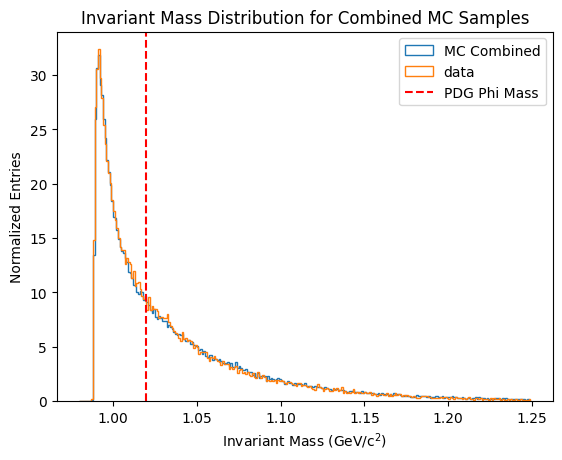

In [9]:
plt.hist(df_combined_study['M'], bins=np.arange(.980,1.250,0.001), range=(0,1.5), histtype='step', label='MC Combined', density=True)
plt.hist(df_data_study['M'], bins=np.arange(.980,1.250,0.001), range=(0,1.5), histtype='step', label='data', density=True)
#plt.hist(df_phiKK_study['M'], bins=np.arange(.980,1.250,0.001), range=(0,1.5), histtype='step', label='PhiKK', density=True)
plt.axvline(x=1.019461, color='r', linestyle='--', label='PDG Phi Mass')

plt.legend()
plt.xlabel('Invariant Mass (GeV/c$^2$)')
plt.ylabel('Normalized Entries')
plt.title('Invariant Mass Distribution for Combined MC Samples')

Text(0, 0.5, 'Normalized Entries')

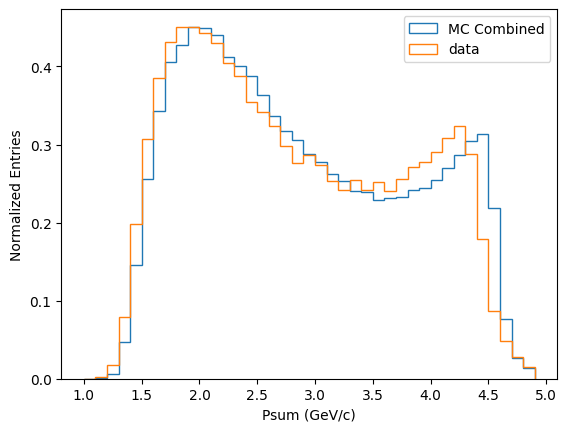

In [10]:
plt.hist(df_combined_study['Ptot'], bins=np.arange(1,5.0,0.1), histtype='step', label='MC Combined', density=True)
plt.hist(df_data_study['Ptot'], bins=np.arange(1,5.0,0.1), histtype='step', label='data', density=True)
#plt.hist(df_phiKK_study['Ptot'], bins=np.arange(1,5.0,0.1), histtype='step', label='PhiKK', density=True)


plt.legend()
plt.xlabel('Psum (GeV/c)')
plt.ylabel('Normalized Entries')


Text(0, 0.5, 'Normalized Entries')

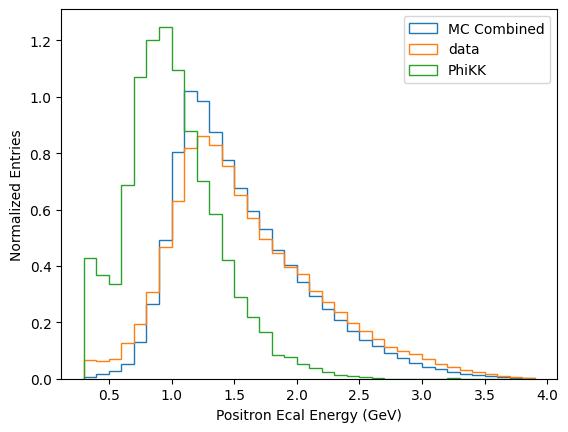

In [11]:
plt.hist(df_combined_study['pos_E_Ecal'], bins=np.arange(.3,4,0.1), range=(0,1.5), histtype='step', label='MC Combined', density=True)
plt.hist(df_data_study['pos_E_Ecal'], bins=np.arange(.3,4,0.1), range=(0,1.5), histtype='step', label='data', density=True)
plt.hist(df_phiKK_study['pos_E_Ecal'], bins=np.arange(.3,4,0.1), range=(0,1.5), histtype='step', label='PhiKK', density=True)


plt.legend()
plt.xlabel('Positron Ecal Energy (GeV)')
plt.ylabel('Normalized Entries')


Text(0, 0.5, 'Normalized Entries')

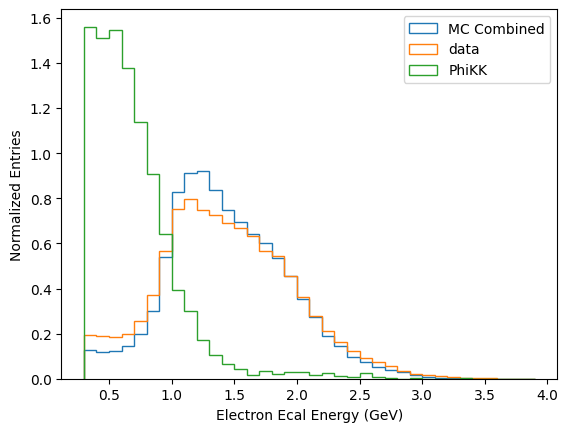

In [12]:
plt.hist(df_combined_study['ele_E_Ecal'], bins=np.arange(.3,4,0.1), range=(0,1.5), histtype='step', label='MC Combined', density=True)
plt.hist(df_data_study['ele_E_Ecal'], bins=np.arange(.3,4,0.1), range=(0,1.5), histtype='step', label='data', density=True)
plt.hist(df_phiKK_study['ele_E_Ecal'], bins=np.arange(.3,4,0.1), range=(0,1.5), histtype='step', label='PhiKK', density=True)


plt.legend()
plt.xlabel('Electron Ecal Energy (GeV)')
plt.ylabel('Normalized Entries')


Text(0, 0.5, 'Normalized Entries')

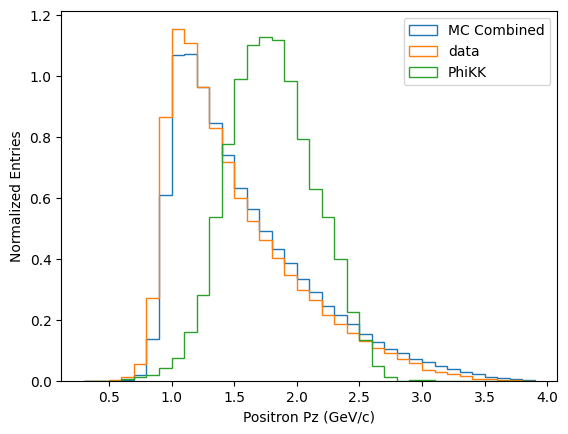

In [13]:
plt.hist(df_combined_study['pos_Pz'], bins=np.arange(.3,4,0.1), range=(0,1.5), histtype='step', label='MC Combined', density=True)
plt.hist(df_data_study['pos_Pz'], bins=np.arange(.3,4,0.1), range=(0,1.5), histtype='step', label='data', density=True)
plt.hist(df_phiKK_study['pos_Pz'], bins=np.arange(.3,4,0.1), range=(0,1.5), histtype='step', label='PhiKK', density=True)


plt.legend()
plt.xlabel('Positron Pz (GeV/c)')
plt.ylabel('Normalized Entries')


Text(0, 0.5, 'Normalized Entries')

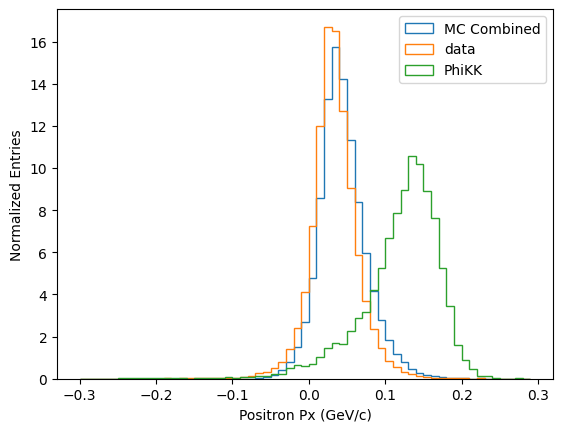

In [14]:
plt.hist(df_combined_study['pos_Px'], bins=np.arange(-.3,.3,0.01), range=(0,1.5), histtype='step', label='MC Combined', density=True)
plt.hist(df_data_study['pos_Px'], bins=np.arange(-.3,.3,0.01), range=(0,1.5), histtype='step', label='data', density=True)
plt.hist(df_phiKK_study['pos_Px'], bins=np.arange(-.3,.3,0.01), range=(0,1.5), histtype='step', label='PhiKK', density=True)


plt.legend()
plt.xlabel('Positron Px (GeV/c)')
plt.ylabel('Normalized Entries')


Text(0, 0.5, 'Normalized Entries')

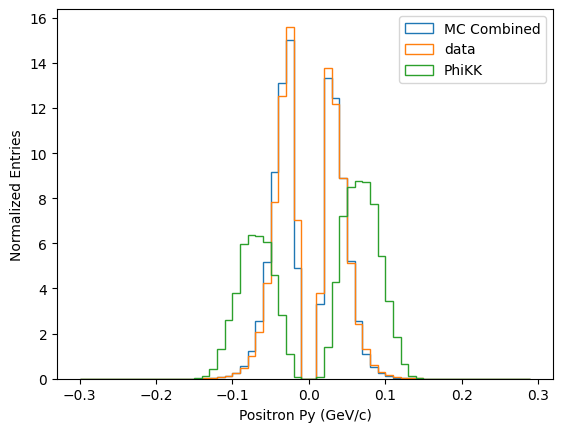

In [15]:
plt.hist(df_combined_study['pos_Py'], bins=np.arange(-.3,.3,0.01), range=(0,1.5), histtype='step', label='MC Combined', density=True)
plt.hist(df_data_study['pos_Py'], bins=np.arange(-.3,.3,0.01), range=(0,1.5), histtype='step', label='data', density=True)
plt.hist(df_phiKK_study['pos_Py'], bins=np.arange(-.3,.3,0.01), range=(0,1.5), histtype='step', label='PhiKK', density=True)


plt.legend()
plt.xlabel('Positron Py (GeV/c)')
plt.ylabel('Normalized Entries')


Text(0, 0.5, 'Normalized Entries')

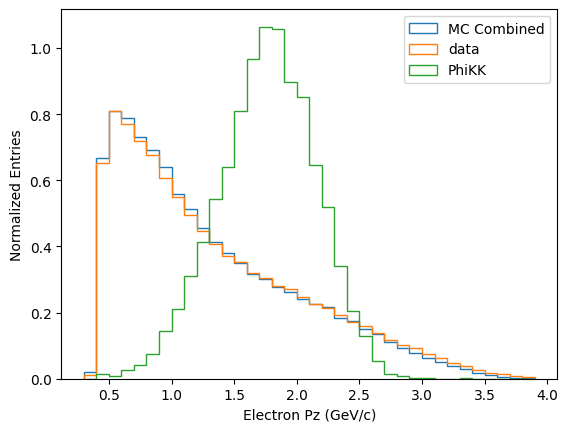

In [16]:
plt.hist(df_combined_study['ele_Pz'], bins=np.arange(.3,4,0.1), range=(0,1.5), histtype='step', label='MC Combined', density=True)
plt.hist(df_data_study['ele_Pz'], bins=np.arange(.3,4,0.1), range=(0,1.5), histtype='step', label='data', density=True)
plt.hist(df_phiKK_study['ele_Pz'], bins=np.arange(.3,4,0.1), range=(0,1.5), histtype='step', label='PhiKK', density=True)


plt.legend()
plt.xlabel('Electron Pz (GeV/c)')
plt.ylabel('Normalized Entries')


Text(0, 0.5, 'Normalized Entries')

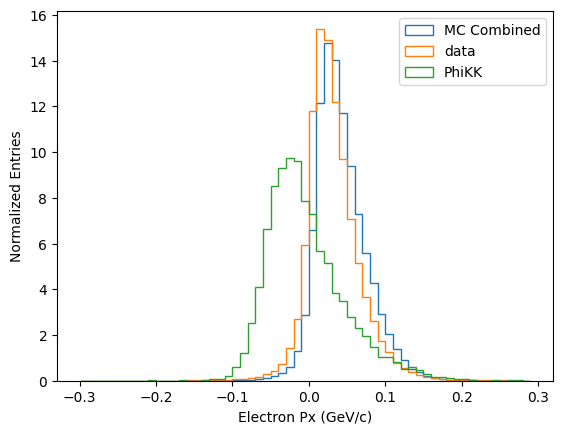

In [17]:
plt.hist(df_combined_study['ele_Px'], bins=np.arange(-.3,.3,0.01), range=(0,1.5), histtype='step', label='MC Combined', density=True)
plt.hist(df_data_study['ele_Px'], bins=np.arange(-.3,.3,0.01), range=(0,1.5), histtype='step', label='data', density=True)
plt.hist(df_phiKK_study['ele_Px'], bins=np.arange(-.3,.3,0.01), range=(0,1.5), histtype='step', label='PhiKK', density=True)


plt.legend()
plt.xlabel('Electron Px (GeV/c)')
plt.ylabel('Normalized Entries')


Text(0, 0.5, 'Normalized Entries')

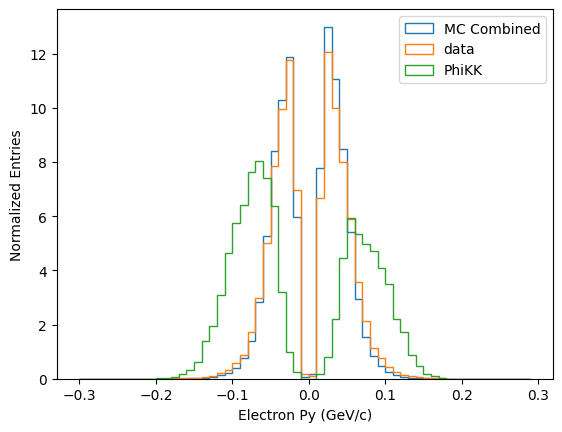

In [18]:
plt.hist(df_combined_study['ele_Py'], bins=np.arange(-.3,.3,0.01), range=(0,1.5), histtype='step', label='MC Combined', density=True)
plt.hist(df_data_study['ele_Py'], bins=np.arange(-.3,.3,0.01), range=(0,1.5), histtype='step', label='data', density=True)
plt.hist(df_phiKK_study['ele_Py'], bins=np.arange(-.3,.3,0.01), range=(0,1.5), histtype='step', label='PhiKK', density=True)


plt.legend()
plt.xlabel('Electron Py (GeV/c)')
plt.ylabel('Normalized Entries')


Text(0, 0.5, 'Normalized Entries')

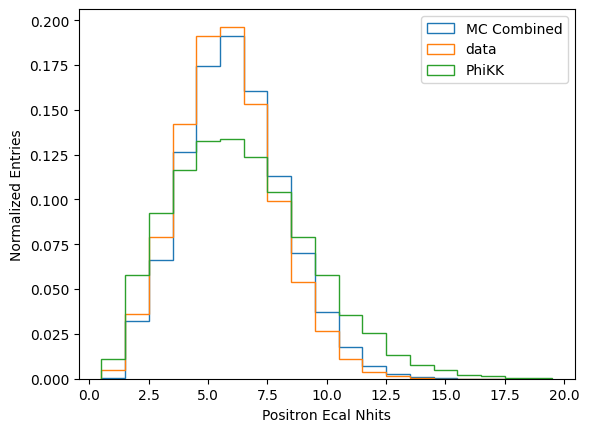

In [19]:
plt.hist(df_combined_study['pos_Ecal_nhits'], bins=np.arange(0.5,20,1), range=(0,1.5), histtype='step', label='MC Combined', density=True)
plt.hist(df_data_study['pos_Ecal_nhits'], bins=np.arange(.5,20,1), range=(0,1.5), histtype='step', label='data', density=True)
plt.hist(df_phiKK_study['pos_Ecal_nhits'], bins=np.arange(0.5,20,1), range=(0,1.5), histtype='step', label='PhiKK', density=True)


plt.legend()
plt.xlabel('Positron Ecal Nhits')
plt.ylabel('Normalized Entries')


Text(0, 0.5, 'Normalized Entries')

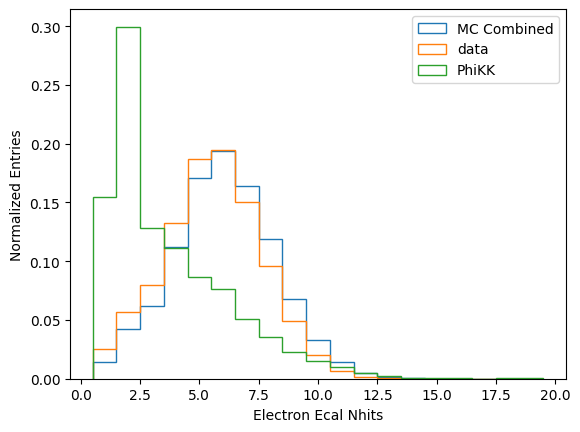

In [20]:
plt.hist(df_combined_study['ele_Ecal_nhits'], bins=np.arange(0.5,20,1), range=(0,1.5), histtype='step', label='MC Combined', density=True)
plt.hist(df_data_study['ele_Ecal_nhits'], bins=np.arange(.5,20,1), range=(0,1.5), histtype='step', label='data', density=True)
plt.hist(df_phiKK_study['ele_Ecal_nhits'], bins=np.arange(0.5,20,1), range=(0,1.5), histtype='step', label='PhiKK', density=True)


plt.legend()
plt.xlabel('Electron Ecal Nhits')
plt.ylabel('Normalized Entries')


Text(0, 0.5, 'Normalized Entries')

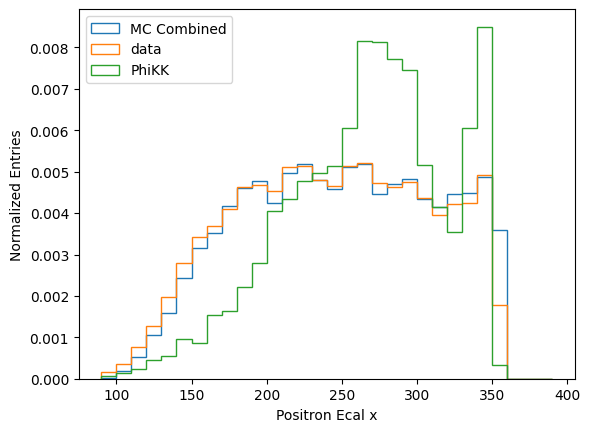

In [21]:
plt.hist(df_combined_study['pos_Ecal_x'], bins=np.arange(90,400,10), range=(0,1.5), histtype='step', label='MC Combined', density=True)
plt.hist(df_data_study['pos_Ecal_x'], bins=np.arange(90,400,10), range=(0,1.5), histtype='step', label='data', density=True)
plt.hist(df_phiKK_study['pos_Ecal_x'], bins=np.arange(90,400,10), range=(0,1.5), histtype='step', label='PhiKK', density=True)


plt.legend()
plt.xlabel('Positron Ecal x')
plt.ylabel('Normalized Entries')


Text(0, 0.5, 'Normalized Entries')

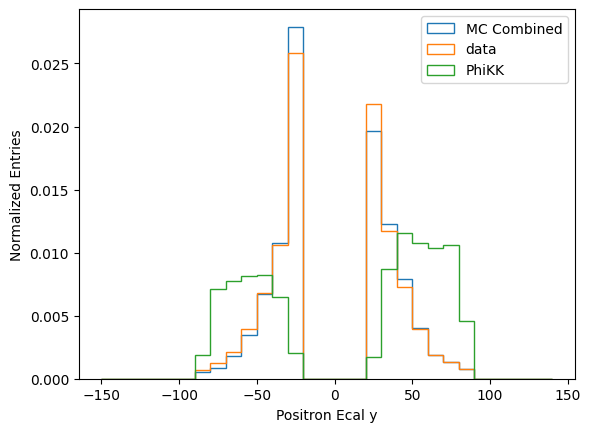

In [22]:
plt.hist(df_combined_study['pos_Ecal_y'], bins=np.arange(-150,150,10), range=(0,1.5), histtype='step', label='MC Combined', density=True)
plt.hist(df_data_study['pos_Ecal_y'], bins=np.arange(-150,150,10), range=(0,1.5), histtype='step', label='data', density=True)
plt.hist(df_phiKK_study['pos_Ecal_y'], bins=np.arange(-150,150,10), range=(0,1.5), histtype='step', label='PhiKK', density=True)


plt.legend()
plt.xlabel('Positron Ecal y')
plt.ylabel('Normalized Entries')


Text(0, 0.5, 'Normalized Entries')

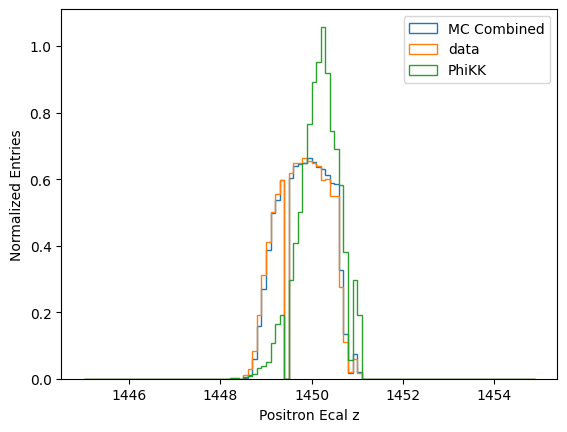

In [23]:
plt.hist(df_combined_study['pos_Ecal_z'], bins=np.arange(1445,1455,.1), range=(0,1.5), histtype='step', label='MC Combined', density=True)
plt.hist(df_data_study['pos_Ecal_z'], bins=np.arange(1445,1455,.1), range=(0,1.5), histtype='step', label='data', density=True)
plt.hist(df_phiKK_study['pos_Ecal_z'], bins=np.arange(1445,1455,.1), range=(0,1.5), histtype='step', label='PhiKK', density=True)


plt.legend()
plt.xlabel('Positron Ecal z')
plt.ylabel('Normalized Entries')


Text(0, 0.5, 'Normalized Entries')

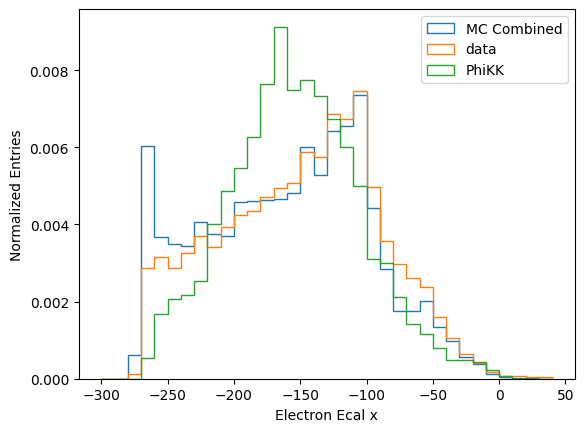

In [24]:
plt.hist(df_combined_study['ele_Ecal_x'], bins=np.arange(-300,50,10), histtype='step', label='MC Combined', density=True)
plt.hist(df_data_study['ele_Ecal_x'], bins=np.arange(-300,50,10), histtype='step', label='data', density=True)
plt.hist(df_phiKK_study['ele_Ecal_x'], bins=np.arange(-300,50,10), histtype='step', label='PhiKK', density=True)


plt.legend()
plt.xlabel('Electron Ecal x')
plt.ylabel('Normalized Entries')


Text(0, 0.5, 'Normalized Entries')

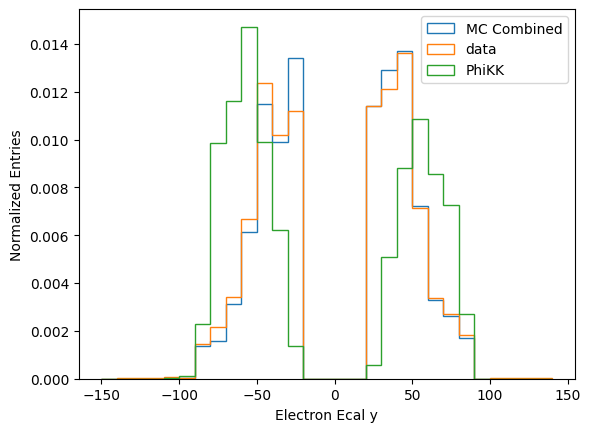

In [25]:
plt.hist(df_combined_study['ele_Ecal_y'], bins=np.arange(-150,150,10), range=(0,1.5), histtype='step', label='MC Combined', density=True)
plt.hist(df_data_study['ele_Ecal_y'], bins=np.arange(-150,150,10), range=(0,1.5), histtype='step', label='data', density=True)
plt.hist(df_phiKK_study['ele_Ecal_y'], bins=np.arange(-150,150,10), range=(0,1.5), histtype='step', label='PhiKK', density=True)


plt.legend()
plt.xlabel('Electron Ecal y')
plt.ylabel('Normalized Entries')


Text(0, 0.5, 'Normalized Entries')

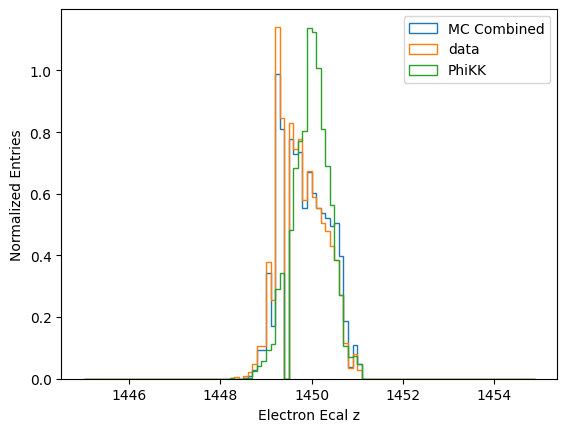

In [26]:
plt.hist(df_combined_study['ele_Ecal_z'], bins=np.arange(1445,1455,.1), range=(0,1.5), histtype='step', label='MC Combined', density=True)
plt.hist(df_data_study['ele_Ecal_z'], bins=np.arange(1445,1455,.1), range=(0,1.5), histtype='step', label='data', density=True)
plt.hist(df_phiKK_study['ele_Ecal_z'], bins=np.arange(1445,1455,.1), range=(0,1.5), histtype='step', label='PhiKK', density=True)


plt.legend()
plt.xlabel('Electron Ecal z')
plt.ylabel('Normalized Entries')
